# Trans-SVNet Results Dashboard

This notebook scans the evaluation outputs from:

- `./Trans-SVNet`
- `./Trans-SVNet_CRF18`
- `./Trans-SVNet_CRF23`
- `./Trans-SVNet_CRF28`
- `./Trans-SVNet_CRF35`
- `./Trans-SVNet_CRF51`

under `/export/fs06/ahallur1/cholec80`, recomputes metrics from exported phase files, and generates a comprehensive set of visualizations.

It is designed for the current evaluation setup:

- ground truth from `phase_annotations`
- 1 fps evaluation
- test videos `49` to `80`
- predictions from each repo under `eval/phase`

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, jaccard_score, confusion_matrix
import json
import math

BASE_DIR = Path("/export/fs06/ahallur1/cholec80")
TEST_START = 49
TEST_END = 80
PHASES = [
    "Preparation",
    "CalotTriangleDissection",
    "ClippingCutting",
    "GallbladderDissection",
    "GallbladderPackaging",
    "CleaningCoagulation",
    "GallbladderRetraction",
]
PHASE_TO_IDX = {name: i for i, name in enumerate(PHASES)}

CONDITION_REPOS = {
    "Original": BASE_DIR / "Trans-SVNet",
    "CRF18": BASE_DIR / "Trans-SVNet_CRF18",
    "CRF23": BASE_DIR / "Trans-SVNet_CRF23",
    "CRF28": BASE_DIR / "Trans-SVNet_CRF28",
    "CRF35": BASE_DIR / "Trans-SVNet_CRF35",
    "CRF51": BASE_DIR / "Trans-SVNet_CRF51",
}

GT_DIR = BASE_DIR / "phase_annotations"
assert GT_DIR.exists(), f"Missing ground-truth folder: {GT_DIR}"

existing = {k: v for k, v in CONDITION_REPOS.items() if v.exists()}
missing = {k: str(v) for k, v in CONDITION_REPOS.items() if not v.exists()}

print("Found repos:")
for k, v in existing.items():
    print(f"  {k:8s} -> {v}")
if missing:
    print("\nMissing repos:")
    for k, v in missing.items():
        print(f"  {k:8s} -> {v}")

Found repos:
  Original -> /export/fs06/ahallur1/cholec80/Trans-SVNet
  CRF18    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF18
  CRF23    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF23
  CRF28    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF28
  CRF35    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF35
  CRF51    -> /export/fs06/ahallur1/cholec80/Trans-SVNet_CRF51


In [3]:
def read_gt_1fps(gt_path: Path):
    labels = []
    with gt_path.open("r") as f:
        next(f)  # header
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2:
                continue
            frame_idx = int(parts[0])
            phase_name = parts[1]
            if frame_idx % 25 != 0:
                continue
            labels.append(PHASE_TO_IDX[phase_name])
    return np.asarray(labels, dtype=np.int64)

def read_pred_txt(pred_path: Path):
    labels = []
    with pred_path.open("r") as f:
        next(f)  # header
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2:
                continue
            labels.append(int(parts[1]))
    return np.asarray(labels, dtype=np.int64)

def compute_condition_metrics(condition_name, repo_root):
    pred_dir = repo_root / "eval" / "phase"
    if not pred_dir.exists():
        raise FileNotFoundError(f"{condition_name}: missing prediction dir {pred_dir}")

    video_rows = []
    all_gt = []
    all_pred = []

    for vid in range(TEST_START, TEST_END + 1):
        video_name = f"video{vid:02d}"
        gt_path = GT_DIR / f"{video_name}-phase.txt"
        pred_path = pred_dir / f"{video_name}-phase.txt"
        if not pred_path.exists():
            raise FileNotFoundError(f"{condition_name}: missing prediction file {pred_path}")

        gt = read_gt_1fps(gt_path)
        pred = read_pred_txt(pred_path)

        usable = min(len(gt), len(pred))
        gt = gt[:usable]
        pred = pred[:usable]

        acc = (gt == pred).mean()
        prec = precision_score(gt, pred, labels=list(range(7)), average=None, zero_division=0)
        rec = recall_score(gt, pred, labels=list(range(7)), average=None, zero_division=0)
        jac = jaccard_score(gt, pred, labels=list(range(7)), average=None, zero_division=0)

        video_rows.append({
            "condition": condition_name,
            "video": video_name,
            "frames": usable,
            "accuracy": float(acc),
            "precision_macro": float(np.mean(prec)),
            "recall_macro": float(np.mean(rec)),
            "jaccard_macro": float(np.mean(jac)),
            **{f"prec_{PHASES[i]}": float(prec[i]) for i in range(7)},
            **{f"rec_{PHASES[i]}": float(rec[i]) for i in range(7)},
            **{f"jac_{PHASES[i]}": float(jac[i]) for i in range(7)},
        })

        all_gt.append(gt)
        all_pred.append(pred)

    all_gt = np.concatenate(all_gt)
    all_pred = np.concatenate(all_pred)

    phase_prec = precision_score(all_gt, all_pred, labels=list(range(7)), average=None, zero_division=0)
    phase_rec = recall_score(all_gt, all_pred, labels=list(range(7)), average=None, zero_division=0)
    phase_jac = jaccard_score(all_gt, all_pred, labels=list(range(7)), average=None, zero_division=0)
    cm = confusion_matrix(all_gt, all_pred, labels=list(range(7)))

    summary = {
        "condition": condition_name,
        "videos": len(video_rows),
        "frames_total": int(sum(r["frames"] for r in video_rows)),
        "mean_video_accuracy": float(np.mean([r["accuracy"] for r in video_rows])),
        "std_video_accuracy": float(np.std([r["accuracy"] for r in video_rows])),
        "mean_video_precision": float(np.mean([r["precision_macro"] for r in video_rows])),
        "mean_video_recall": float(np.mean([r["recall_macro"] for r in video_rows])),
        "mean_video_jaccard": float(np.mean([r["jaccard_macro"] for r in video_rows])),
        **{f"phase_prec_{PHASES[i]}": float(phase_prec[i]) for i in range(7)},
        **{f"phase_rec_{PHASES[i]}": float(phase_rec[i]) for i in range(7)},
        **{f"phase_jac_{PHASES[i]}": float(phase_jac[i]) for i in range(7)},
        "confusion_matrix": cm.tolist(),
    }

    return pd.DataFrame(video_rows), summary, all_gt, all_pred, cm

video_dfs = []
summaries = []
gt_pred_store = {}

for condition_name, repo_root in existing.items():
    df, summary, all_gt, all_pred, cm = compute_condition_metrics(condition_name, repo_root)
    video_dfs.append(df)
    summaries.append(summary)
    gt_pred_store[condition_name] = {"gt": all_gt, "pred": all_pred, "cm": cm}

video_df = pd.concat(video_dfs, ignore_index=True)
summary_df = pd.DataFrame(summaries).drop(columns=["confusion_matrix"])
summary_df = summary_df.sort_values("condition").reset_index(drop=True)

print("Per-condition summary:")
summary_df[["condition", "videos", "frames_total", "mean_video_accuracy", "mean_video_precision", "mean_video_recall", "mean_video_jaccard"]]

Per-condition summary:


,condition,videos,frames_total,mean_video_accuracy,mean_video_precision,mean_video_recall,mean_video_jaccard
0,CRF18,32,76757,0.875548,0.827477,0.825757,0.706039
1,CRF23,32,76757,0.887577,0.840626,0.825874,0.717169
2,CRF28,32,76757,0.892972,0.840313,0.839702,0.725396
3,CRF35,32,76757,0.882015,0.830128,0.810388,0.698499
4,CRF51,32,76757,0.807330,0.781081,0.754764,0.620746
5,Original,32,76757,0.867586,0.832310,0.816491,0.702053


## Summary table

The table below recomputes the metrics directly from the exported prediction files and ground truth, so it is independent of the console logs.

In [4]:
summary_display = summary_df[[
    "condition", "videos", "frames_total",
    "mean_video_accuracy", "std_video_accuracy",
    "mean_video_precision", "mean_video_recall", "mean_video_jaccard"
]].copy()

for c in ["mean_video_accuracy", "std_video_accuracy", "mean_video_precision", "mean_video_recall", "mean_video_jaccard"]:
    summary_display[c] = (summary_display[c] * 100).round(2)

summary_display

,condition,videos,frames_total,mean_video_accuracy,std_video_accuracy,mean_video_precision,mean_video_recall,mean_video_jaccard
0,CRF18,32,76757,87.55,7.56,82.75,82.58,70.60
1,CRF23,32,76757,88.76,6.27,84.06,82.59,71.72
2,CRF28,32,76757,89.30,6.51,84.03,83.97,72.54
3,CRF35,32,76757,88.20,6.67,83.01,81.04,69.85
4,CRF51,32,76757,80.73,11.93,78.11,75.48,62.07
5,Original,32,76757,86.76,8.53,83.23,81.65,70.21


## Sanity checks

These checks help confirm the outputs are structurally consistent across conditions.

In [5]:
checks = (
    video_df.groupby("condition")
    .agg(
        videos=("video", "nunique"),
        total_frames=("frames", "sum"),
        min_video_accuracy=("accuracy", "min"),
        max_video_accuracy=("accuracy", "max"),
    )
    .reset_index()
)
checks[["min_video_accuracy", "max_video_accuracy"]] = checks[["min_video_accuracy", "max_video_accuracy"]] * 100
checks.round(2)

,condition,videos,total_frames,min_video_accuracy,max_video_accuracy
0,CRF18,32,76757,64.53,96.24
1,CRF23,32,76757,73.03,98.01
2,CRF28,32,76757,73.15,96.61
3,CRF35,32,76757,66.74,96.31
4,CRF51,32,76757,53.37,97.35
5,Original,32,76757,60.55,97.49


## Metric comparison across compression levels

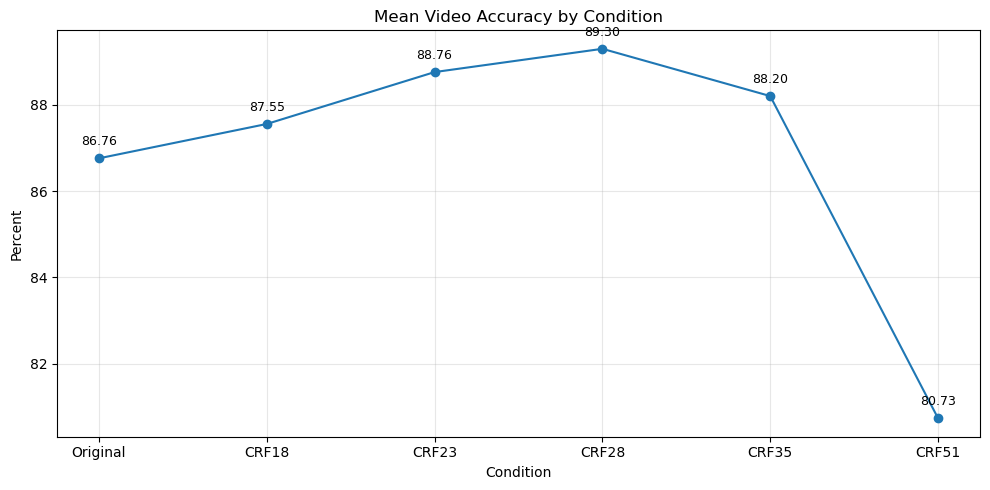

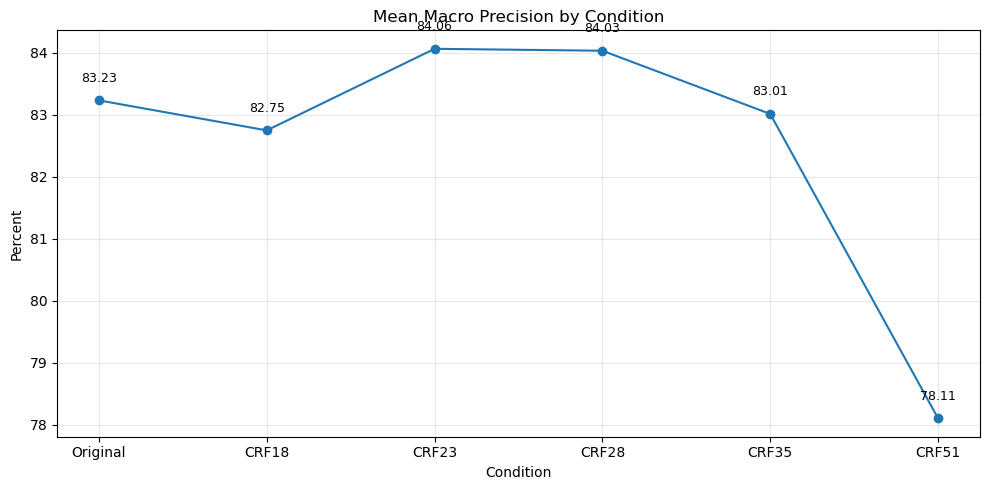

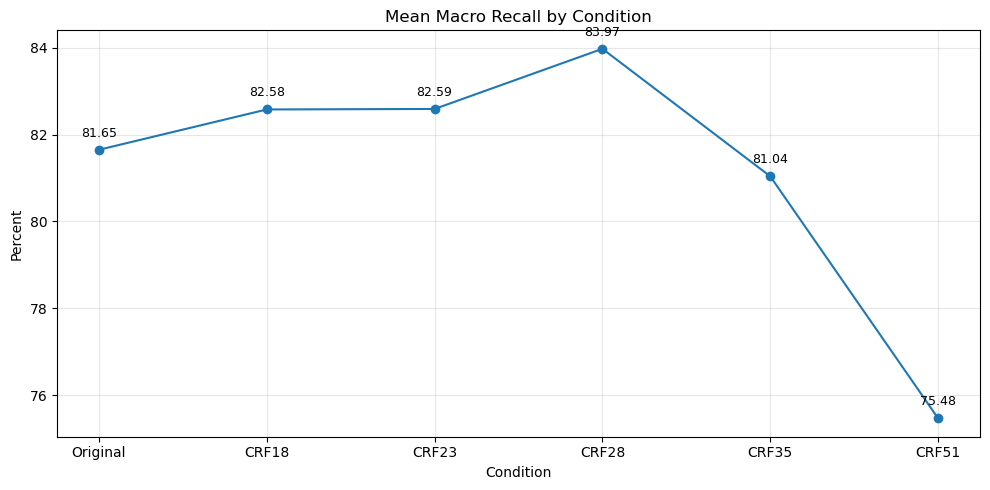

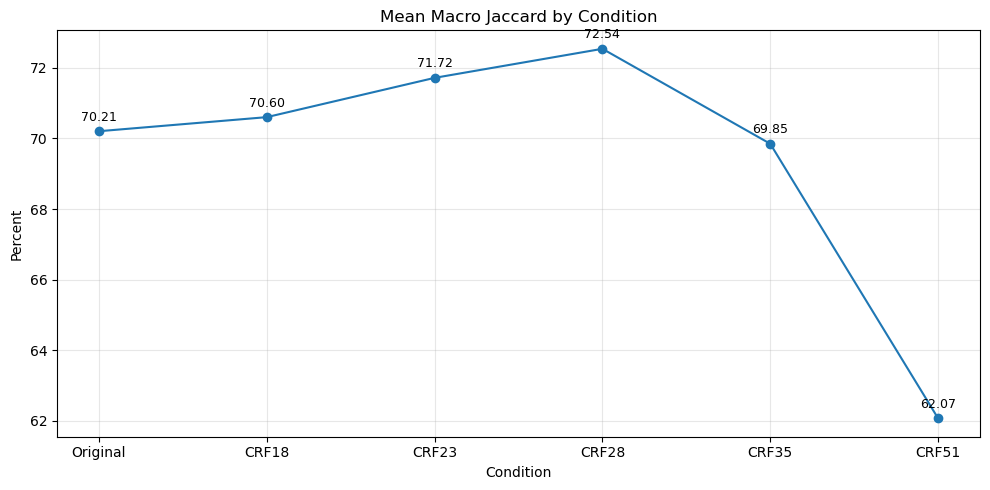

In [6]:
plot_df = summary_df.copy()
conditions_in_order = ["Original", "CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=conditions_in_order, ordered=True)
plot_df = plot_df.sort_values("condition")

for metric, title in [
    ("mean_video_accuracy", "Mean Video Accuracy by Condition"),
    ("mean_video_precision", "Mean Macro Precision by Condition"),
    ("mean_video_recall", "Mean Macro Recall by Condition"),
    ("mean_video_jaccard", "Mean Macro Jaccard by Condition"),
]:
    plt.figure(figsize=(10, 5))
    plt.plot(plot_df["condition"], plot_df[metric] * 100, marker="o")
    for x, y in zip(plot_df["condition"], plot_df[metric] * 100):
        plt.text(x, y + 0.3, f"{y:.2f}", ha="center", fontsize=9)
    plt.ylabel("Percent")
    plt.xlabel("Condition")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Ranking conditions by metric

In [7]:
rank_df = summary_df[["condition", "mean_video_accuracy", "mean_video_precision", "mean_video_recall", "mean_video_jaccard"]].copy()
for col in ["mean_video_accuracy", "mean_video_precision", "mean_video_recall", "mean_video_jaccard"]:
    rank_df[col] = (rank_df[col] * 100).round(2)

rank_df.sort_values("mean_video_jaccard", ascending=False)

,condition,mean_video_accuracy,mean_video_precision,mean_video_recall,mean_video_jaccard
2,CRF28,89.30,84.03,83.97,72.54
1,CRF23,88.76,84.06,82.59,71.72
0,CRF18,87.55,82.75,82.58,70.60
5,Original,86.76,83.23,81.65,70.21
3,CRF35,88.20,83.01,81.04,69.85
4,CRF51,80.73,78.11,75.48,62.07


## Per-video accuracy across conditions

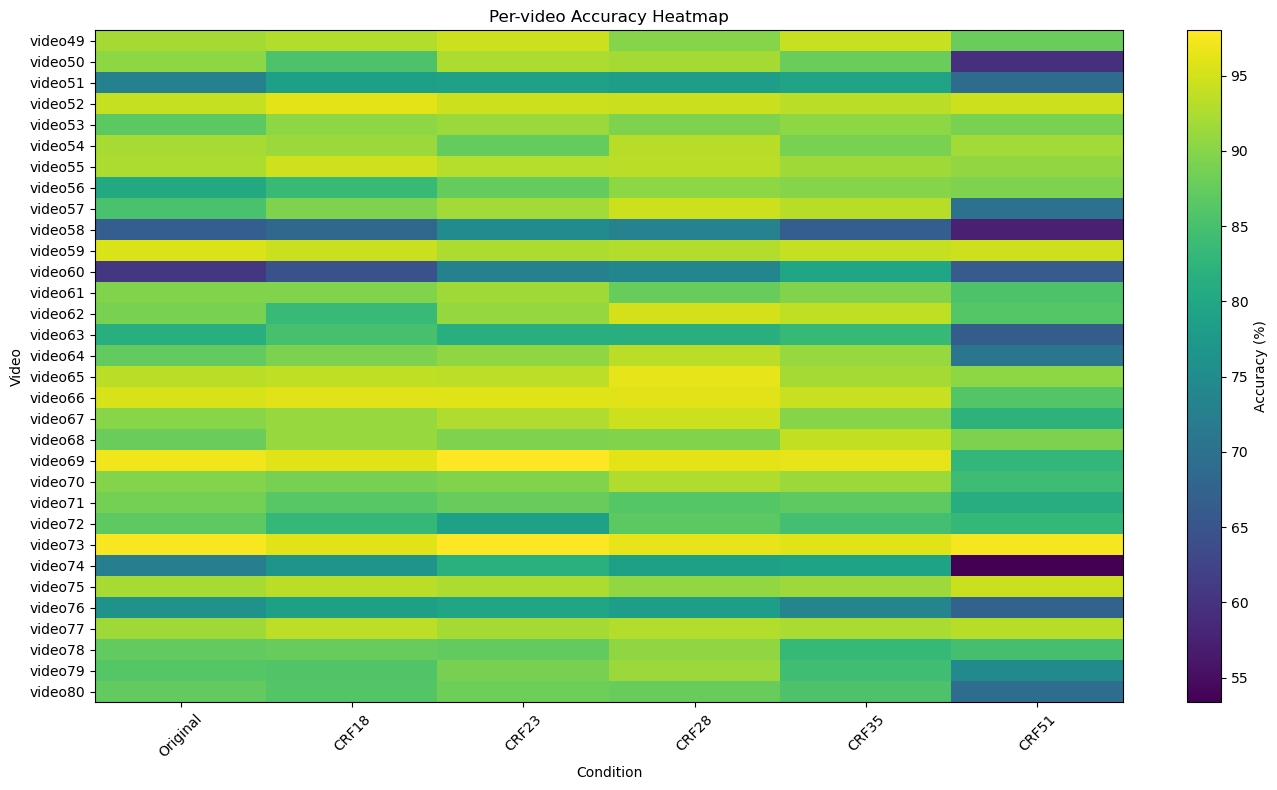

In [8]:
pivot_acc = video_df.pivot(index="video", columns="condition", values="accuracy")
pivot_acc = pivot_acc[conditions_in_order]
plt.figure(figsize=(14, 8))
im = plt.imshow(pivot_acc.values * 100, aspect="auto")
plt.yticks(range(len(pivot_acc.index)), pivot_acc.index)
plt.xticks(range(len(pivot_acc.columns)), pivot_acc.columns, rotation=45)
plt.colorbar(im, label="Accuracy (%)")
plt.title("Per-video Accuracy Heatmap")
plt.xlabel("Condition")
plt.ylabel("Video")
plt.tight_layout()
plt.show()

## Which videos are hardest or easiest?

In [9]:
video_avg = (
    video_df.groupby("video")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_jaccard=("jaccard_macro", "mean"),
    )
    .reset_index()
)
video_avg["mean_accuracy_pct"] = video_avg["mean_accuracy"] * 100
video_avg["mean_jaccard_pct"] = video_avg["mean_jaccard"] * 100

hardest = video_avg.sort_values("mean_accuracy").head(10)
easiest = video_avg.sort_values("mean_accuracy", ascending=False).head(10)

print("Hardest videos across conditions:")
display(hardest[["video", "mean_accuracy_pct", "std_accuracy", "mean_jaccard_pct"]].round(2))

print("Easiest videos across conditions:")
display(easiest[["video", "mean_accuracy_pct", "std_accuracy", "mean_jaccard_pct"]].round(2))

Hardest videos across conditions:


,video,mean_accuracy_pct,std_accuracy,mean_jaccard_pct
9,video58,67.90,0.06,53.47
11,video60,69.59,0.07,54.20
25,video74,73.68,0.10,60.23
27,video76,75.68,0.04,59.38
2,video51,76.22,0.04,68.28
14,video63,79.81,0.07,51.84
23,video72,83.92,0.03,70.44
31,video80,84.04,0.07,61.86
1,video50,84.63,0.13,52.70
30,video79,85.18,0.06,61.81


Easiest videos across conditions:


,video,mean_accuracy_pct,std_accuracy,mean_jaccard_pct
24,video73,96.88,0.01,90.06
3,video52,94.55,0.01,87.62
20,video69,94.42,0.06,71.98
10,video59,94.01,0.01,81.50
17,video66,93.87,0.04,79.90
16,video65,93.23,0.02,65.65
6,video55,92.67,0.01,77.52
28,video77,92.63,0.01,77.83
26,video75,92.48,0.01,62.13
0,video49,91.91,0.03,79.90


## Accuracy distributions by condition

/tmp/ipykernel_1072945/2994538109.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)


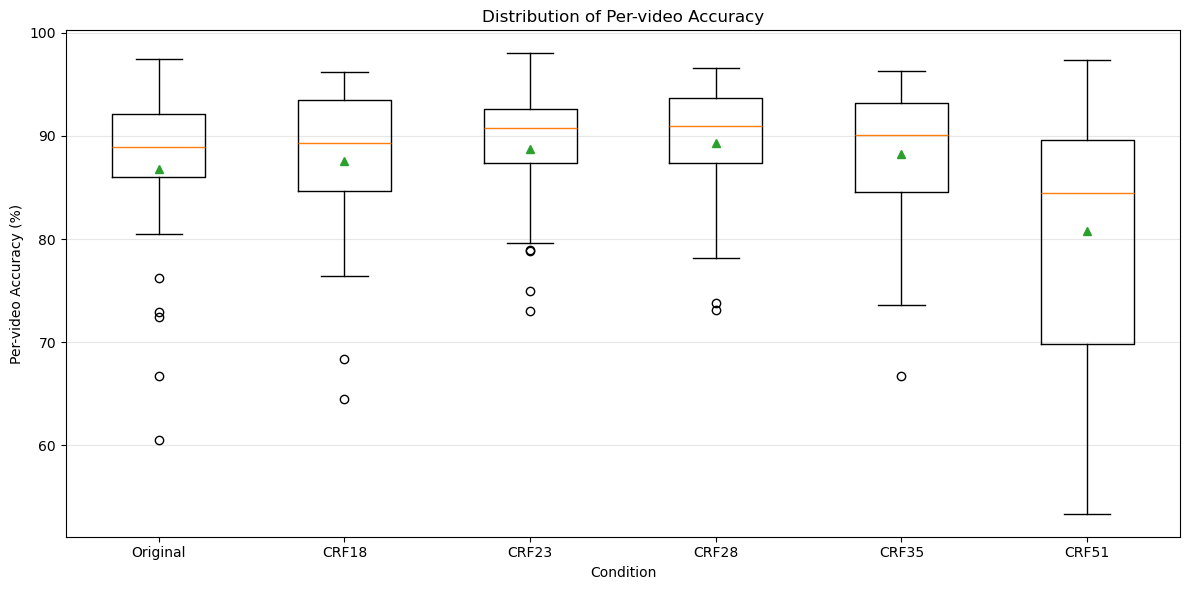

In [10]:
plt.figure(figsize=(12, 6))
data = []
labels = []
for cond in conditions_in_order:
    if cond in set(video_df["condition"]):
        data.append((video_df.loc[video_df["condition"] == cond, "accuracy"] * 100).values)
        labels.append(cond)

plt.boxplot(data, labels=labels, showmeans=True)
plt.ylabel("Per-video Accuracy (%)")
plt.xlabel("Condition")
plt.title("Distribution of Per-video Accuracy")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Compression-vs-original deltas for each video

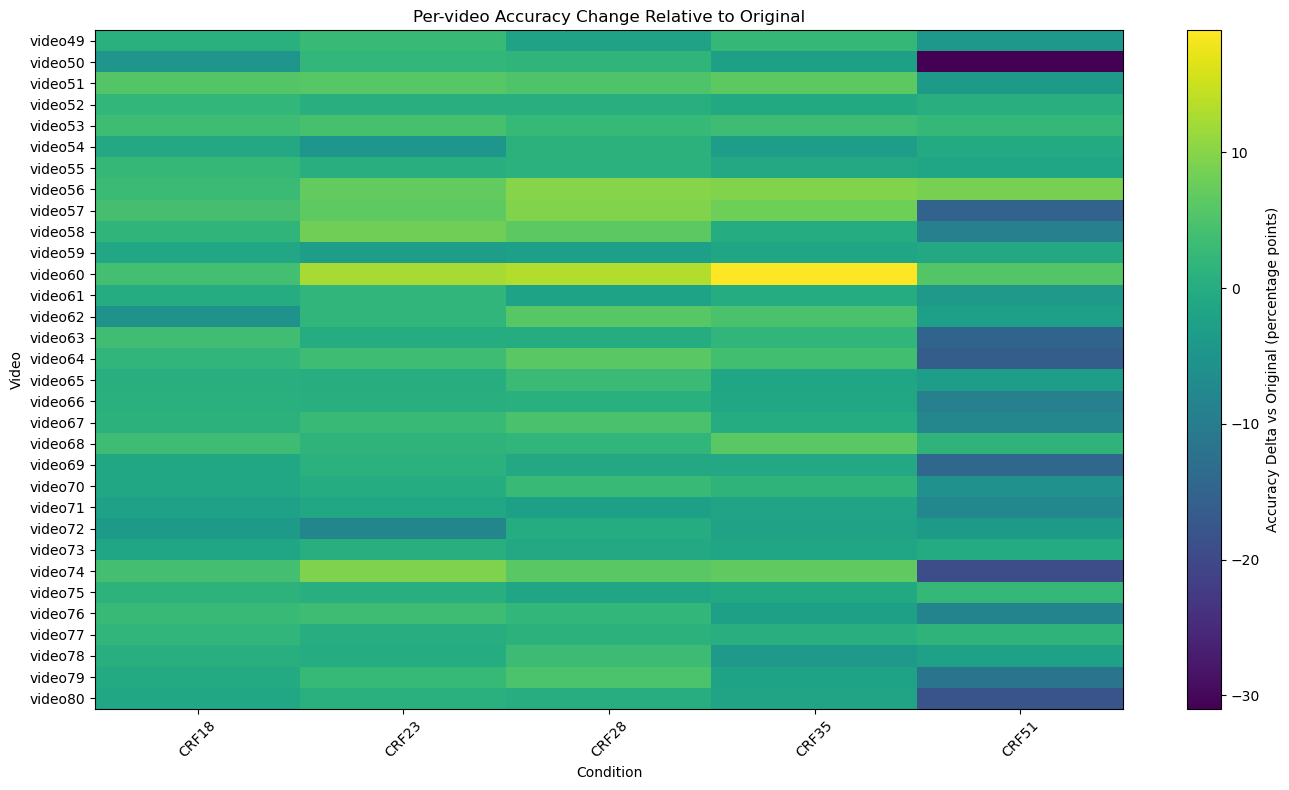

condition
CRF18    0.796216
CRF23    1.999081
CRF28    2.538602
CRF35    1.442856
CRF51   -6.025635
dtype: float64

In [11]:
baseline = pivot_acc["Original"]
delta_df = pivot_acc.subtract(baseline, axis=0)
delta_df = delta_df.drop(columns=["Original"], errors="ignore")

plt.figure(figsize=(14, 8))
im = plt.imshow(delta_df.values * 100, aspect="auto")
plt.yticks(range(len(delta_df.index)), delta_df.index)
plt.xticks(range(len(delta_df.columns)), delta_df.columns, rotation=45)
plt.colorbar(im, label="Accuracy Delta vs Original (percentage points)")
plt.title("Per-video Accuracy Change Relative to Original")
plt.xlabel("Condition")
plt.ylabel("Video")
plt.tight_layout()
plt.show()

delta_summary = (delta_df.mean(axis=0) * 100).sort_index()
delta_summary

## Per-phase performance by condition

In [12]:
phase_metric_rows = []
for _, row in summary_df.iterrows():
    cond = row["condition"]
    for phase in PHASES:
        phase_metric_rows.append({
            "condition": cond,
            "phase": phase,
            "precision": row[f"phase_prec_{phase}"] * 100,
            "recall": row[f"phase_rec_{phase}"] * 100,
            "jaccard": row[f"phase_jac_{phase}"] * 100,
        })

phase_metrics_df = pd.DataFrame(phase_metric_rows)
phase_metrics_df.head()

,condition,phase,precision,recall,jaccard
0,CRF18,Preparation,97.702368,77.466368,76.080374
1,CRF18,CalotTriangleDissection,95.718874,83.764301,80.739442
2,CRF18,ClippingCutting,70.640859,79.688073,59.862164
3,CRF18,GallbladderDissection,85.264388,92.575311,79.806919
4,CRF18,GallbladderPackaging,73.748952,87.466844,66.700379


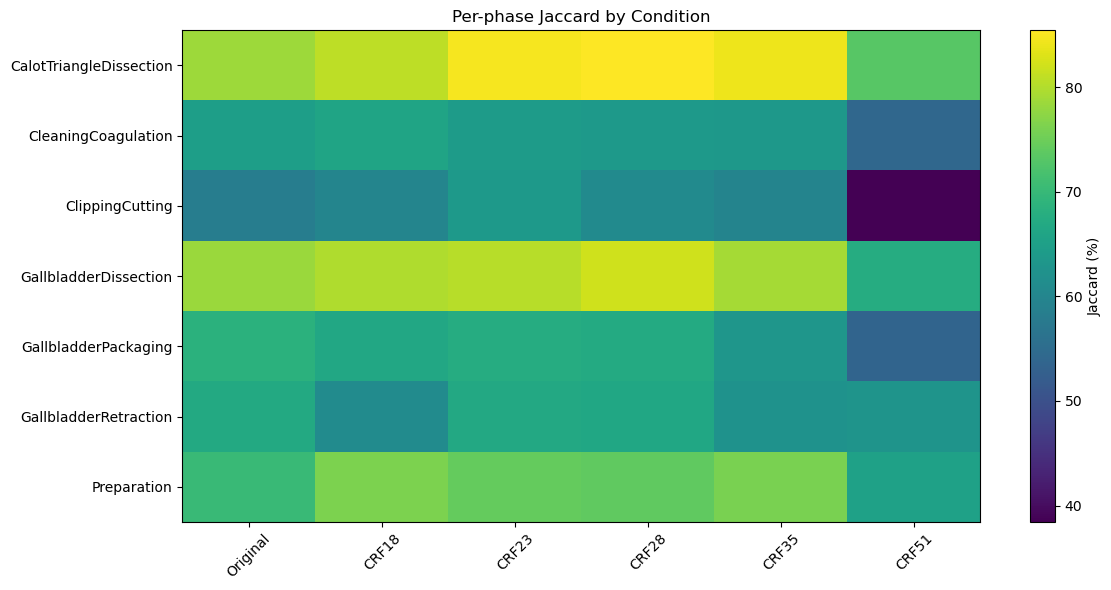

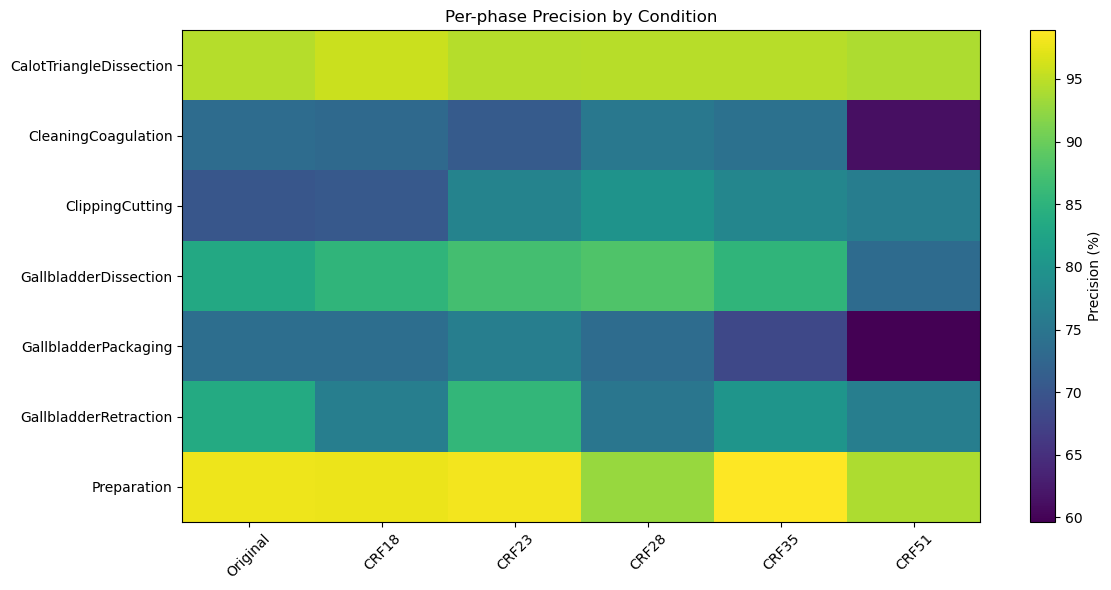

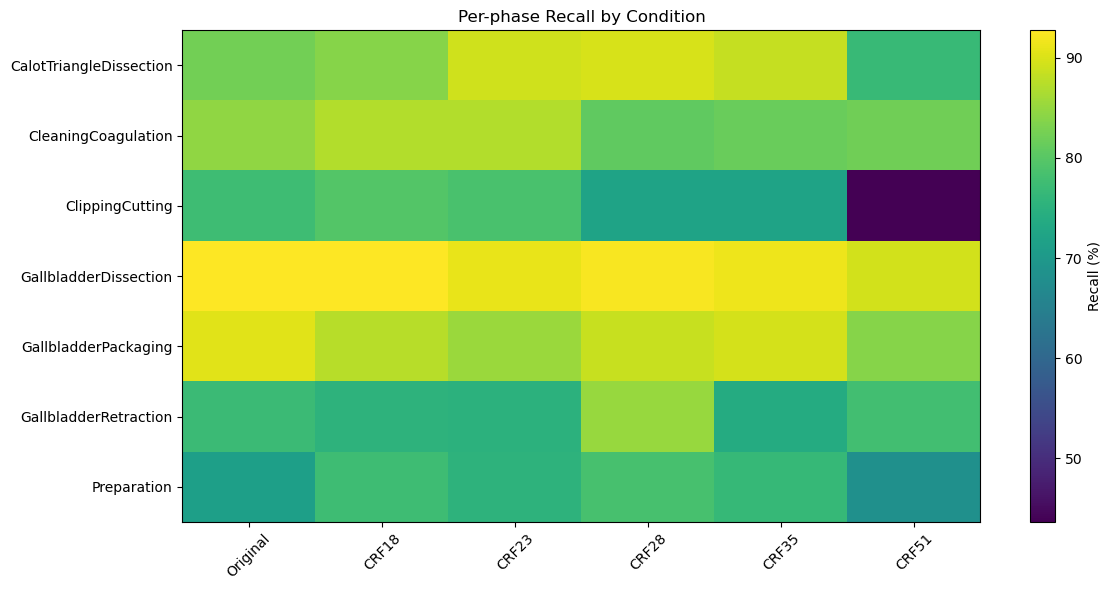

In [13]:
for metric in ["jaccard", "precision", "recall"]:
    pivot = phase_metrics_df.pivot(index="phase", columns="condition", values=metric)
    pivot = pivot[conditions_in_order]

    plt.figure(figsize=(12, 6))
    im = plt.imshow(pivot.values, aspect="auto")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
    plt.colorbar(im, label=f"{metric.title()} (%)")
    plt.title(f"Per-phase {metric.title()} by Condition")
    plt.tight_layout()
    plt.show()

## Phase trend lines across compression levels

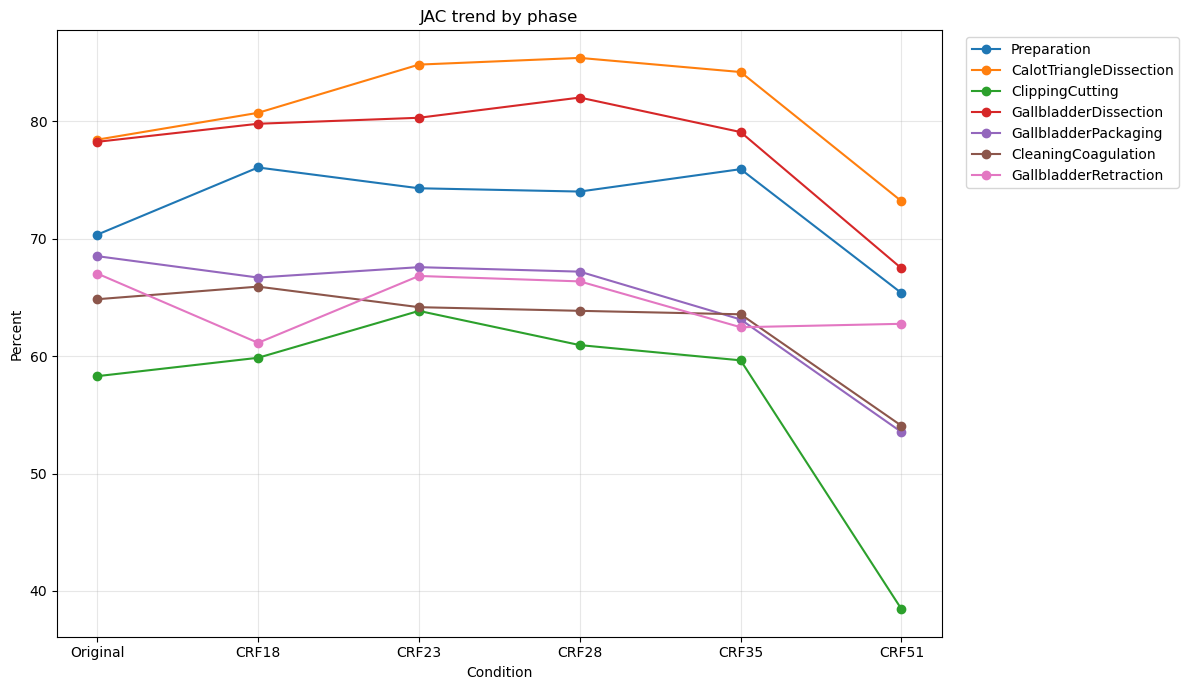

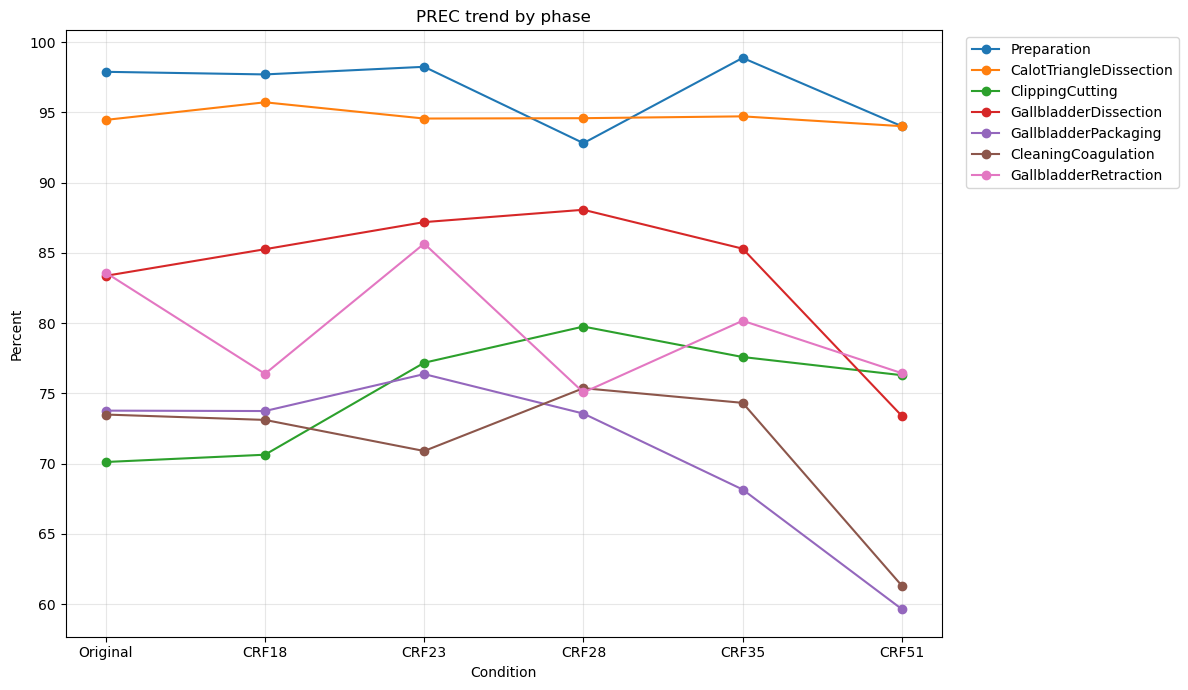

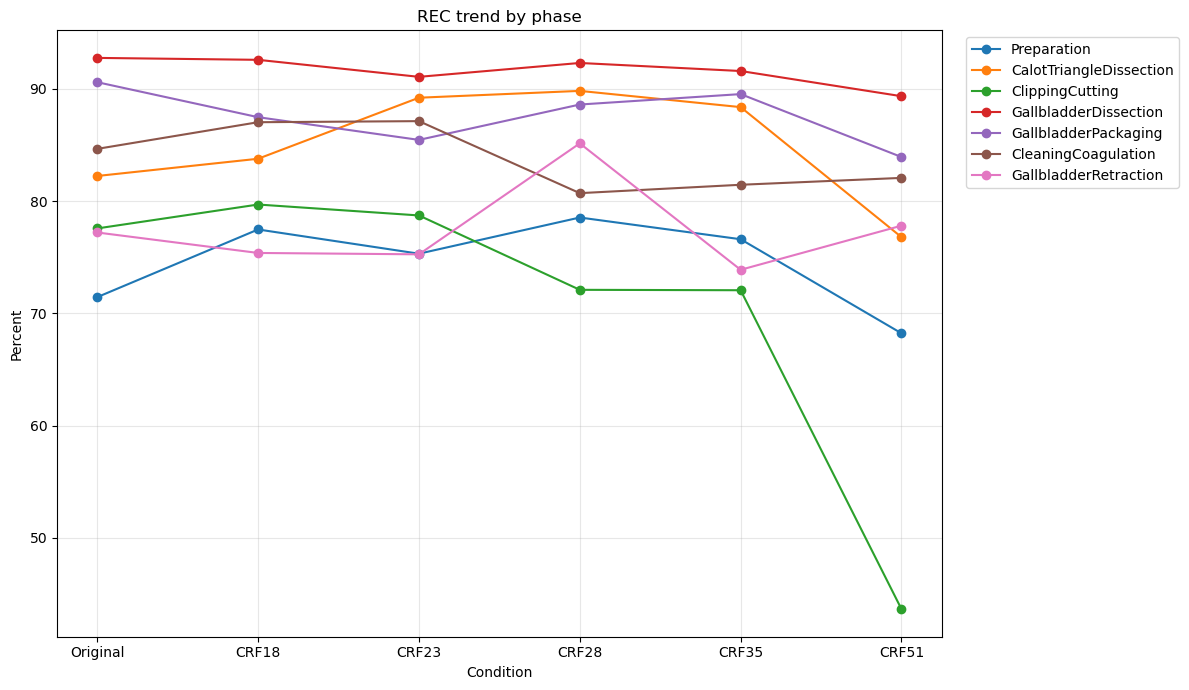

In [14]:
ordered_phases = PHASES
x_labels = [c for c in conditions_in_order if c in set(summary_df["condition"])]

for metric in ["phase_jac_", "phase_prec_", "phase_rec_"]:
    plt.figure(figsize=(12, 7))
    for phase in ordered_phases:
        values = []
        for cond in x_labels:
            row = summary_df.loc[summary_df["condition"] == cond].iloc[0]
            values.append(row[f"{metric}{phase}"] * 100)
        plt.plot(x_labels, values, marker="o", label=phase)
    plt.title(metric.replace("phase_", "").replace("_", "").upper() + " trend by phase")
    plt.ylabel("Percent")
    plt.xlabel("Condition")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Confusion matrices

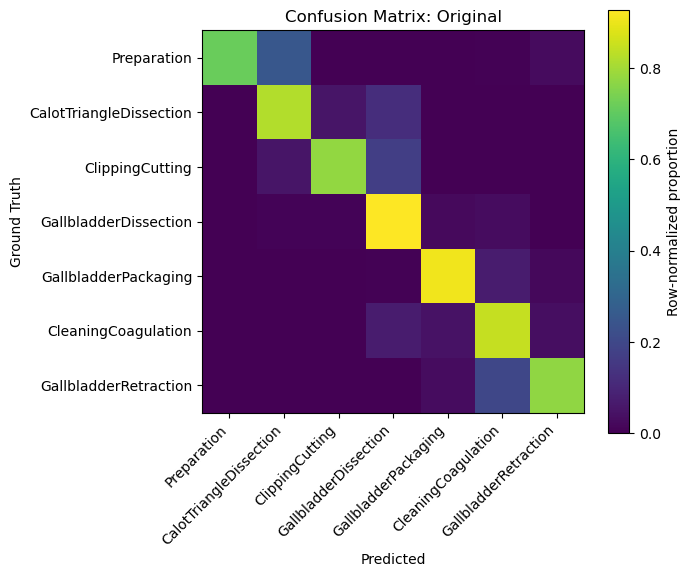

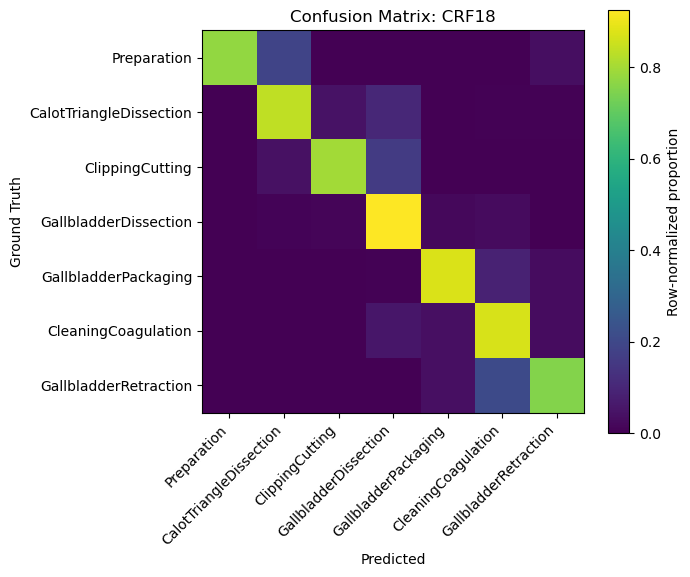

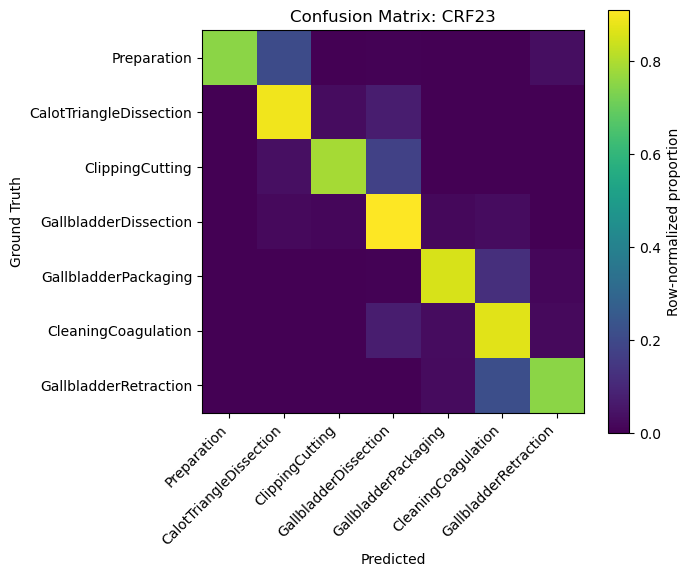

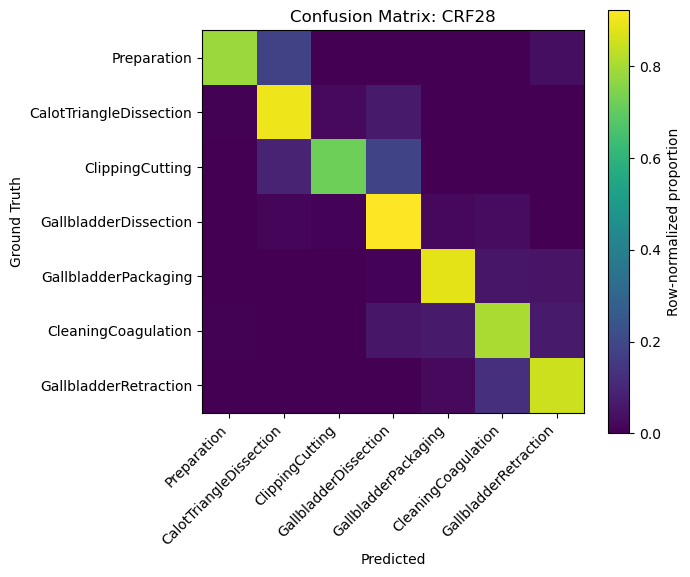

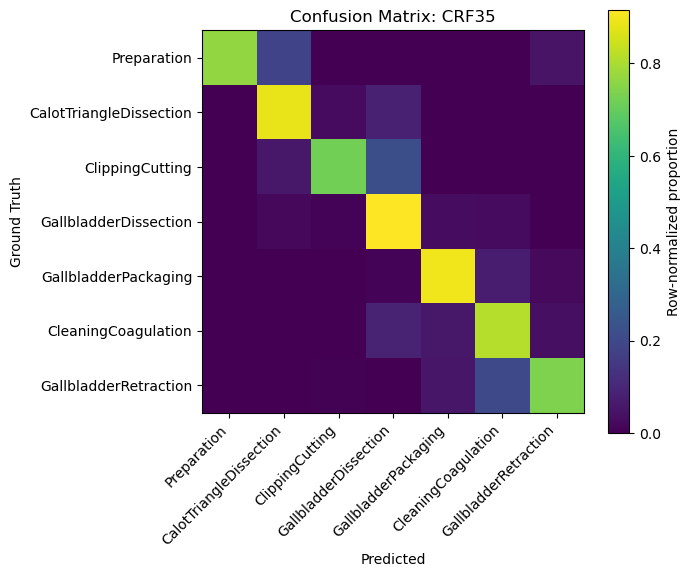

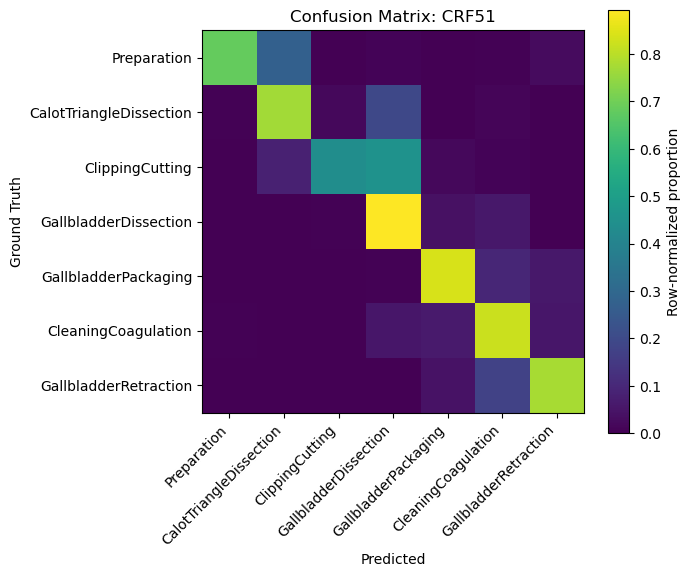

In [15]:
for cond in x_labels:
    cm = np.asarray(gt_pred_store[cond]["cm"], dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums != 0)

    plt.figure(figsize=(7, 6))
    im = plt.imshow(cm_norm)
    plt.xticks(range(len(PHASES)), PHASES, rotation=45, ha="right")
    plt.yticks(range(len(PHASES)), PHASES)
    plt.colorbar(im, label="Row-normalized proportion")
    plt.title(f"Confusion Matrix: {cond}")
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.show()

## Ribbon plots for selected videos

These plots mimic the paper's qualitative ribbon visualizations by comparing ground truth and predictions across conditions for a chosen video. The paper's supplementary page shows this style of video-length ribbon visualization for qualitative comparison. fileciteturn9file0

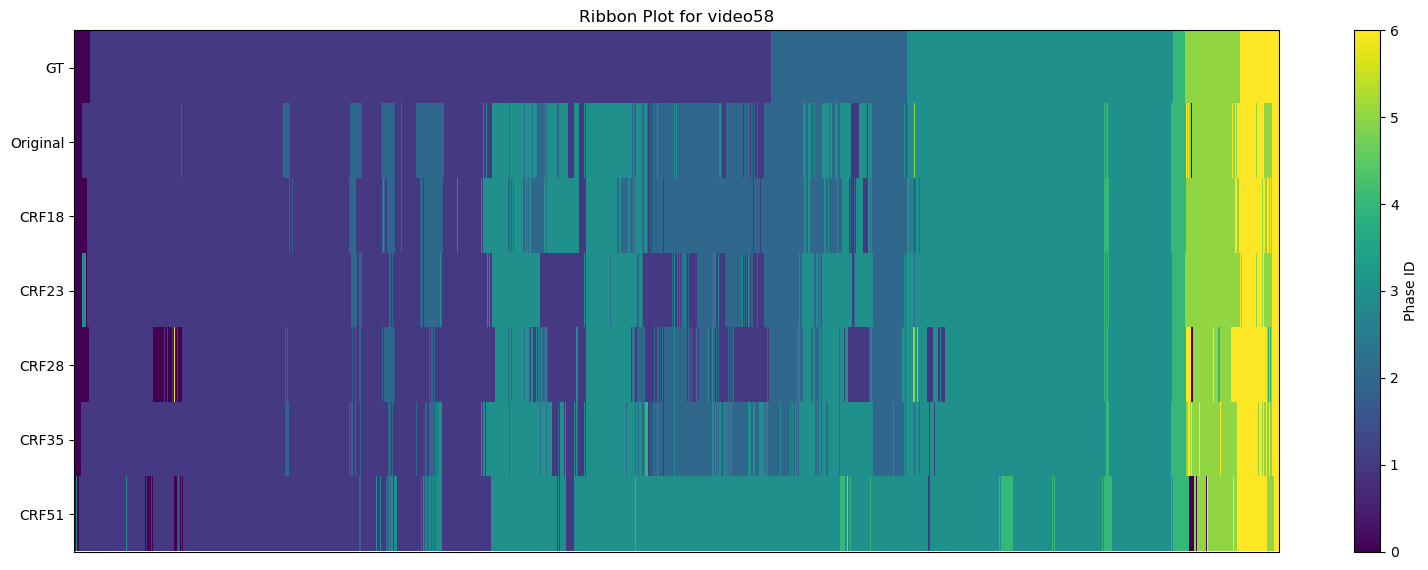

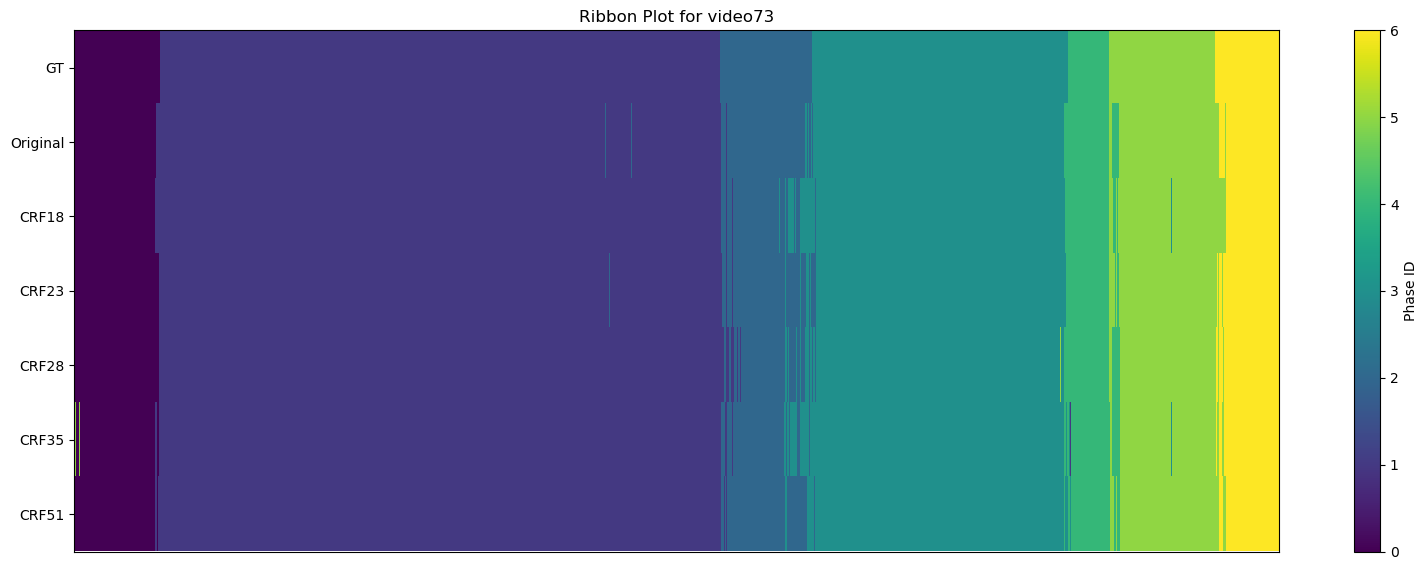

In [16]:
def read_gt_numeric_1fps(video_name):
    gt_path = GT_DIR / f"{video_name}-phase.txt"
    return read_gt_1fps(gt_path)

def read_pred_numeric(condition, video_name):
    pred_path = CONDITION_REPOS[condition] / "eval" / "phase" / f"{video_name}-phase.txt"
    return read_pred_txt(pred_path)

def ribbon_plot(video_name):
    rows = []
    labels = []

    gt = read_gt_numeric_1fps(video_name)
    rows.append(gt)
    labels.append("GT")

    for cond in x_labels:
        pred = read_pred_numeric(cond, video_name)
        usable = min(len(gt), len(pred))
        rows.append(pred[:usable])
        labels.append(cond)

    min_len = min(len(r) for r in rows)
    rows = [r[:min_len] for r in rows]
    mat = np.vstack(rows)

    plt.figure(figsize=(16, 3 + 0.4 * len(rows)))
    im = plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(range(len(labels)), labels)
    plt.xticks([])
    plt.colorbar(im, ticks=range(len(PHASES)), label="Phase ID")
    plt.title(f"Ribbon Plot for {video_name}")
    plt.tight_layout()
    plt.show()

ribbon_plot("video58")
ribbon_plot("video73")

## Relationship between video length and performance

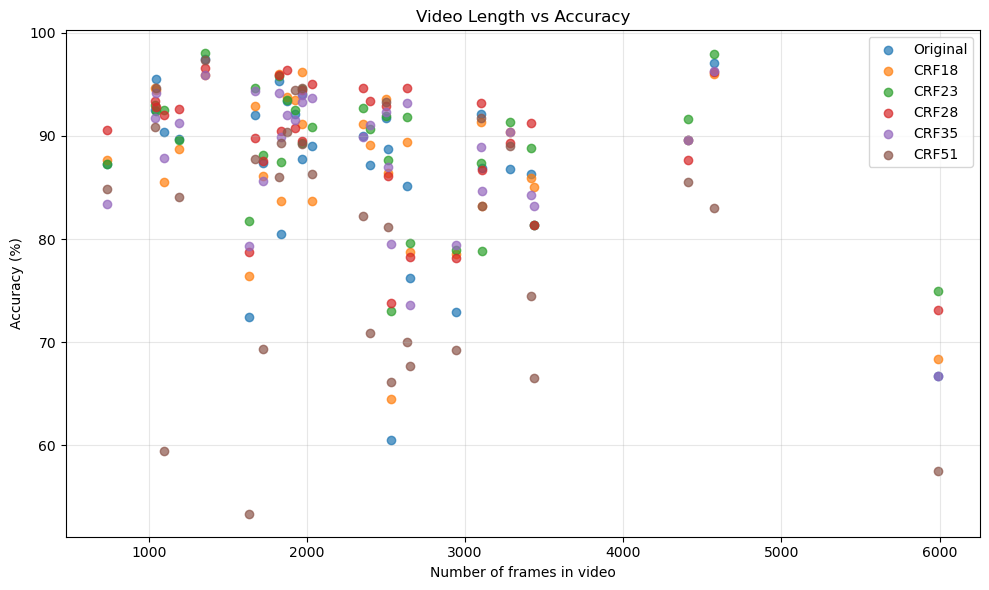

In [17]:
plt.figure(figsize=(10, 6))
for cond in x_labels:
    subset = video_df[video_df["condition"] == cond]
    plt.scatter(subset["frames"], subset["accuracy"] * 100, label=cond, alpha=0.7)
plt.xlabel("Number of frames in video")
plt.ylabel("Accuracy (%)")
plt.title("Video Length vs Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save summary tables

This cell writes CSV copies for easier use in papers or slides.

In [18]:
csv_dir = BASE_DIR / "analysis_exports"
csv_dir.mkdir(parents=True, exist_ok=True)

video_df.to_csv(csv_dir / "per_video_metrics.csv", index=False)
summary_df.to_csv(csv_dir / "per_condition_summary.csv", index=False)
phase_metrics_df.to_csv(csv_dir / "per_phase_metrics_by_condition.csv", index=False)

print("Saved:")
for p in [
    csv_dir / "per_video_metrics.csv",
    csv_dir / "per_condition_summary.csv",
    csv_dir / "per_phase_metrics_by_condition.csv",
]:
    print(" ", p)

Saved:
  /export/fs06/ahallur1/cholec80/analysis_exports/per_video_metrics.csv
  /export/fs06/ahallur1/cholec80/analysis_exports/per_condition_summary.csv
  /export/fs06/ahallur1/cholec80/analysis_exports/per_phase_metrics_by_condition.csv


## Quick interpretation notes

This notebook lets you answer questions like:

- Which compression setting performs best overall?
- Which videos are consistently hardest across all conditions?
- Which phases degrade the most at stronger compression?
- Does moderate compression ever outperform the original condition?
- Which confusion patterns become more common as compression increases?

Because all metrics are recomputed from exported predictions, this notebook gives you one centralized analysis layer across all runs.